# Chapter 6: Writing Web Crawlers

### The Dark and Deep Webs

* You’ve likely heard the terms *deep web*, *dark web*, or *hidden web* being thrown around a lot, especially in the media lately. What do they mean? The deep web is any part of the web that’s not part of the *surface web*. The surface is part of the internet that is indexed by search engines. Estimates vary widely, but the deep web almost certainly makes up about 90% of the internet. Because Google can’t do things like submit forms, find pages that haven’t been linked to by a top-level domain, or investigate sites where *robots.txt* prohibits it, the surface web stays relatively small.

* The *dark web*, also known as the darknet, is another beast entirely. It is run over the existing network hardware infrastructure but uses Tor, or another client, with an application protocol that runs on top of HTTP, providing a secure channel to exchange information. Although it is possible to scrape the dark web, just as you’d scrape any other website, doing so is outside the scope of this book.

* Unlike the dark web, the deep web is relatively easy to scrape. Many tools in this book will teach you how to crawl and scrape information from many places that Google bots can’t go.

In [1]:
import re
import random
from datetime import datetime
from urllib.parse import urlparse
from urllib.request import urlopen

import requests
from bs4 import BeautifulSoup

In [2]:
url = "https://en.wikipedia.org/wiki/Kevin_Bacon"
headers = {"User-Agent": "Mr.Robot-Linux_Machine"}

html = requests.get(url, headers=headers)
html

<Response [200]>

In [3]:
bs = BeautifulSoup(html.text, "lxml")

for link in bs.find_all("a"):
    print(link.get("href"))

#bodyContent
/wiki/Main_Page
/wiki/Wikipedia:Contents
/wiki/Portal:Current_events
/wiki/Special:Random
/wiki/Wikipedia:About
//en.wikipedia.org/wiki/Wikipedia:Contact_us
/wiki/Help:Contents
/wiki/Help:Introduction
/wiki/Wikipedia:Community_portal
/wiki/Special:RecentChanges
/wiki/Wikipedia:File_upload_wizard
/wiki/Special:SpecialPages
/wiki/Main_Page
/wiki/Special:Search
https://donate.wikimedia.org/?wmf_source=donate&wmf_medium=sidebar&wmf_campaign=en.wikipedia.org&uselang=en
/w/index.php?title=Special:CreateAccount&returnto=Kevin+Bacon
/w/index.php?title=Special:UserLogin&returnto=Kevin+Bacon
https://donate.wikimedia.org/?wmf_source=donate&wmf_medium=sidebar&wmf_campaign=en.wikipedia.org&uselang=en
/w/index.php?title=Special:CreateAccount&returnto=Kevin+Bacon
/w/index.php?title=Special:UserLogin&returnto=Kevin+Bacon
#
#Early_life_and_education
#Acting_career
#Early_work
#1980s
#1990s
#2000s
#2010s
#Other_ventures
#Six_Degrees_of_Kevin_Bacon
#Personal_life
#Accolades
#Awards_and_nomin

In [4]:
for link in bs.find("div", {"id": "bodyContent"}).find_all(
    "a", href=re.compile("^(/wiki/)((?!:).)*$")):
    print(link.attrs['href'])

/wiki/Kevin_Bacon_(disambiguation)
/wiki/Philadelphia
/wiki/Kevin_Bacon_filmography
/wiki/Kyra_Sedgwick
/wiki/Sosie_Bacon
/wiki/Edmund_Bacon_(architect)
/wiki/Michael_Bacon_(composer)
/wiki/Leading_man
/wiki/Golden_Globe_Award
/wiki/Actor_Award
/wiki/National_Lampoon%27s_Animal_House
/wiki/Diner_(1982_film)
/wiki/Footloose_(1984_film)
/wiki/JFK_(film)
/wiki/A_Few_Good_Men
/wiki/Apollo_13_(film)
/wiki/Mystic_River_(film)
/wiki/Frost/Nixon_(film)
/wiki/Friday_the_13th_(1980_film)
/wiki/Tremors_(1990_film)
/wiki/The_River_Wild
/wiki/Balto_(film)
/wiki/The_Woodsman_(2004_film)
/wiki/Crazy,_Stupid,_Love
/wiki/Patriots_Day_(film)
/wiki/Losing_Chase
/wiki/Loverboy_(2005_film)
/wiki/Golden_Globe_Award_for_Best_Actor_%E2%80%93_Miniseries_or_Television_Film
/wiki/Screen_Actors_Guild_Award_for_Outstanding_Performance_by_a_Male_Actor_in_a_Miniseries_or_Television_Movie
/wiki/Michael_Strobl
/wiki/HBO
/wiki/Taking_Chance
/wiki/Fox_Broadcasting_Company
/wiki/The_Following
/wiki/Amazon_Prime_Video
/wi

In [5]:
for link in bs.find_all(
    "a", href=re.compile("^/wiki/((?!Main_Page|Talk_Page|:).)*$")):
    print(link.attrs['href'])

/wiki/Kevin_Bacon
/wiki/Kevin_Bacon
/wiki/Kevin_Bacon
/wiki/Kevin_Bacon_(disambiguation)
/wiki/Philadelphia
/wiki/Kevin_Bacon_filmography
/wiki/Kyra_Sedgwick
/wiki/Sosie_Bacon
/wiki/Edmund_Bacon_(architect)
/wiki/Michael_Bacon_(composer)
/wiki/Leading_man
/wiki/Golden_Globe_Award
/wiki/Actor_Award
/wiki/National_Lampoon%27s_Animal_House
/wiki/Diner_(1982_film)
/wiki/Footloose_(1984_film)
/wiki/JFK_(film)
/wiki/A_Few_Good_Men
/wiki/Apollo_13_(film)
/wiki/Mystic_River_(film)
/wiki/Frost/Nixon_(film)
/wiki/Friday_the_13th_(1980_film)
/wiki/Tremors_(1990_film)
/wiki/The_River_Wild
/wiki/Balto_(film)
/wiki/The_Woodsman_(2004_film)
/wiki/Crazy,_Stupid,_Love
/wiki/Patriots_Day_(film)
/wiki/Losing_Chase
/wiki/Loverboy_(2005_film)
/wiki/Golden_Globe_Award_for_Best_Actor_%E2%80%93_Miniseries_or_Television_Film
/wiki/Screen_Actors_Guild_Award_for_Outstanding_Performance_by_a_Male_Actor_in_a_Miniseries_or_Television_Movie
/wiki/Michael_Strobl
/wiki/HBO
/wiki/Taking_Chance
/wiki/Fox_Broadcasting_Co

In [6]:
random.seed(datetime.now().timestamp())
def get_links(article_url):
    headers = {"User-Agent": "Mr.Robot-Linux_Machine"}
    html = requests.get(f"https://en.wikipedia.org{article_url}", headers=headers)
    bs = BeautifulSoup(html.text, "lxml")
    return bs.find("div", {"id": "bodyContent"}).find_all(
        "a", href=re.compile("^(/wiki/)((?!:).)*$")
    )

In [7]:
links = get_links("/wiki/Technology")
while len(links) > 0:
    new_article = links[random.randint(0, len(links)-1)].attrs["href"]
    print(new_article)
    links = get_links(new_article)

/wiki/Refrigeration
/wiki/Coolgardie_safe
/wiki/Indigenous_Australians
/wiki/ISBN_(identifier)
/wiki/OCR-B
/wiki/Open_Sans
/wiki/Source_Code_Pro
/wiki/Symbols_for_zero#Glyphs
/wiki/APL_syntax_and_symbols#Monadic_functions
/wiki/ISBN_(identifier)
/wiki/ISO_15919
/wiki/ISO_10161
/wiki/ISO_8691
/wiki/ISO_2
/wiki/ISO_8373
/wiki/List_of_uncrewed_spacecraft_by_program
/wiki/List_of_human_spaceflights
/wiki/Shenzhou_6
/wiki/Tianzhou_(spacecraft)
/wiki/Wenchang_Spacecraft_Launch_Site
/wiki/Long_March_5
/wiki/Juno_II
/wiki/Long_March_12A
/wiki/Long_March_4B
/wiki/Proton-K
/wiki/Sounding_rocket
/wiki/Rocket
/wiki/BBC_News
/wiki/The_World_Tonight
/wiki/Geeta_Guru-Murthy
/wiki/Channel_4_News
/wiki/Dermot_Murnaghan
/wiki/Northern_Ireland
/wiki/Free_trade_agreements_of_the_United_Kingdom
/wiki/Brill_Publishers
/wiki/ISBN_(identifier)
/wiki/Linux_Standard_Base
/wiki/BlueZ
/wiki/PCMCIA
/wiki/I3C_(bus)
/wiki/Digital_Control_Bus
/wiki/ISBN_(identifier)
/wiki/Knowledge_Discovery_Metamodel
/wiki/ISO/IEEE_

KeyboardInterrupt: 

In [ ]:
pages = set()
def get_links(article_url):
    headers = {"User-Agent": "Mr.Robot-Linux_Machine"}
    html = requests.get(f"https://en.wikipedia.org{article_url}", headers=headers)
    bs = BeautifulSoup(html.text, "lxml")
    for link in bs.find_all("a", href=re.compile("^(/wiki/)")):
        if link.get("href") in pages:
            continue
        # We have encountered a new page
        new_page = link.attrs["href"]
        print(new_page)
        pages.add(new_page)
        get_links(new_page)

get_links("")

In [ ]:
pages = set()
def get_links(article_url):
    headers = {"User-Agent": "Mr.Robot-Linux_Machine"}
    html = requests.get(f"https://en.wikipedia.org{article_url}", headers=headers)
    bs = BeautifulSoup(html.text, "lxml")
    # bs.find("div", {"id": "bodyContent"}).
    for link in bs.find_all("a", href=re.compile("^(/wiki/)((?!:).)*$")):
        if link.get("href") in pages:
            continue
        # We have encountered a new page
        new_page = link.attrs["href"]
        print(new_page)
        pages.add(new_page)
        get_links(new_page)

get_links("")

In [8]:
pages = set()
def get_links(article_url):
    headers = {"User-Agent": "Mr.Robot-Linux_Machine"}
    html = requests.get(f"https://en.wikipedia.org{article_url}", headers=headers)
    bs = BeautifulSoup(html.text, "lxml")
    try:
        print(bs.h1.get_text())
        print(bs.find(id="mw-content-text").find_all("p")[0].get_text())
        print(bs.find(id="ca-edit").find("span").find("a").get("href"))
    except AttributeError, IndexError:
        # This page is missing something! Continuing.
        pass

    for link in bs.find_all("a", href=re.compile("^(/wiki/)((?!:).)*$")):
        if link.get("href") in pages:
            continue
        # We have encountered a new page
        new_page = link.attrs["href"]
        print("=" * 70)
        print(new_page)
        pages.add(new_page)
        get_links(new_page)

get_links("")

Main Page
The geography and ecology of the Everglades are areas of study of the vast interconnected ecosystems known as the Everglades that once occupied about a third of the southern Florida peninsula. Although sawgrass and sloughs are the enduring geographical icons of the Everglades, other ecosystems are as vital, and the borders marking them are subtle or nonexistent. Pinelands and tropical hardwood hammocks are common; the trees, rooted in soil inches above the peat, marl, or water, support a variety of wildlife. The oldest and tallest trees are cypresses, with roots specially adapted to grow underwater for months at a time. Freshwater from Lake Okeechobee meets saltwater from the Gulf of Mexico, nurturing mangrove forests which harbor many species of birds, fish, and invertebrates. The marine environment of Florida Bay is also considered part of the Everglades. Minor fluctuations in water levels have far-reaching consequences for many species, and the system cycles and pulses wit

KeyboardInterrupt: 

## Crawling Across the Internet

In [3]:
def get_internal_links(bs, url):
    """Retrieves a list of all Internal links found on a page"""
    netloc = urlparse(url).netloc
    scheme = urlparse(url).scheme
    internal_links = set()
    for link in bs.find_all("a"):
        if not link.attrs.get("href"):
            continue
        parsed = urlparse(link.attrs["href"])
        if parsed.netloc == "":
            internal_links.add(f"{scheme}://{netloc}/{link.attrs['href'].strip('/')}")
        elif parsed.netloc == netloc:
            internal_links.add(link.attrs["href"])
    return list(internal_links)


def get_external_links(bs, url):
    """Retrieves a list of all external links found on a page"""
    netloc = urlparse(url).netloc
    external_links = set()
    for link in bs.find_all("a"):
        if not link.attrs.get("href"):
            continue
        parsed = urlparse(link.attrs["href"])
        if parsed.netloc != "" and parsed.netloc != netloc:
            external_links.add(link.attrs["href"])
    return list(external_links)


def get_random_external_link(starting_page):
    # bs = BeautifulSoup(urlopen(starting_page), "lxml")
    bs = BeautifulSoup(
        requests.get(starting_page, headers=headers).text, "lxml"
    )
    external_links = get_external_links(bs, starting_page)
    if not len(external_links):
        print("No external links, looking around the site for one")
        internal_links = get_internal_links(bs, starting_page)
        return get_random_external_link(random.choice(internal_links))
    else:
        return random.choice(external_links)


def follow_external_only(starting_site):
    external_link = get_random_external_link(starting_site)
    print(f"Random external link: {external_link}")
    follow_external_only(external_link)

In [50]:
follow_external_only("https://www.oreilly.com/")

Random external link: https://oreillyradar.substack.com/
Random external link: https://substack.com/tos
Random external link: https://reader.substack.com?utm_source=substack&utm_medium=web&utm_content=footer
Random external link: https://enable-javascript.com/
Random external link: https://ai-text-humanizer.com/
Random external link: https://www.toolpilot.ai/
Random external link: https://www.producthunt.com/products/toolpilot-ai
Random external link: https://x.com/ProductHunt


ConnectionError: HTTPSConnectionPool(host='x.com', port=443): Max retries exceeded with url: /ProductHunt (Caused by NewConnectionError("HTTPSConnection(host='x.com', port=443): Failed to establish a new connection: [Errno 111] Connection refused"))

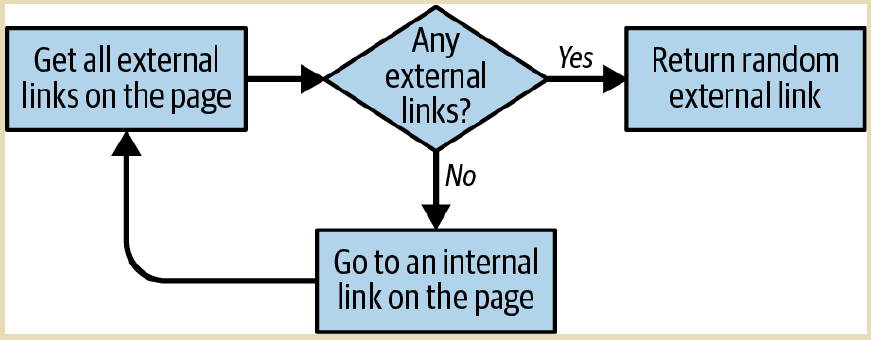

**Figure 6-1: Flowchart for the script that crawls through sites on the internet.**

In [5]:
# Collects a list of all external URLs found on the site
all_ext_links = set()
all_int_links = set()

def get_all_external_links(url):
    bs = BeautifulSoup(
        requests.get(url, headers=headers).text, "lxml"
    )
    internal_links = get_internal_links(bs, url)
    external_links = get_external_links(bs, url)
    for link in external_links:
        if link not in all_ext_links:
            all_ext_links.add(link)
            print(link)

    for link in internal_links:
        if link not in all_int_links:
            all_int_links.add(link)
            get_all_external_links(link)

In [6]:
all_int_links.add("https://oreilly.com")
get_all_external_links("https://oreilly.com")

https://www.oreilly.com/online-learning/individuals.html
https://www.oreilly.com
https://www.oreilly.com/online-learning/teams.html
https://www.oreilly.com/online-learning/oreilly-awards-winners-2025.html
https://oreillyradar.substack.com/
https://www.oreilly.com/modern-slavery-act-transparency-statement.html
https://www.oreilly.com/terms/
https://www.oreilly.co.jp/index.shtml
https://www.oreilly.com/online-learning/verifiable-skills.html
https://itunes.apple.com/us/app/safari-to-go/id881697395
https://www.oreilly.com/online-learning/government.html
https://channelstore.roku.com/details/c9d25fa651f0ad84e484b0dfd4b20172:856a240ad268961983e91ae52c1e1e5c/oreilly
https://www.linkedin.com/company/oreilly-media
https://learning.oreilly.com/search/?query=author%3A%22Neal%20Ford%22&extended_publisher_data=true&highlight=true&include_assessments=false&include_case_studies=true&include_courses=true&include_playlists=true&include_collections=true&include_notebooks=true&include_sandboxes=true&incl

KeyboardInterrupt: 

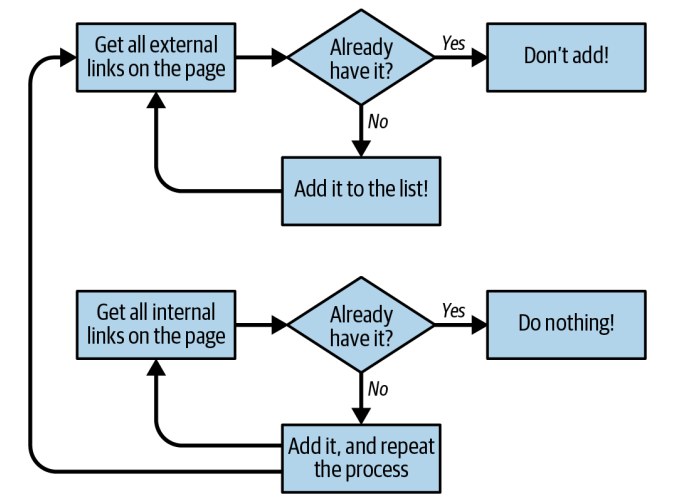

**Figure 6-2: Flow diagram for the website crawler that collects all external links.**